In [1]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)  # empty-slice means etc.

# >>> SET THIS to your WESAD root on Compute Canada <<<
DATA_DIR = Path("WESAD/")   # each subject at DATA_DIR/SX/SX.pkl

# 15 valid subjects (S1, S12 discarded by dataset authors)
SUBJECTS = [f"S{i}" for i in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]]

# Sampling rates (Hz) per the WESAD readme
FS = {
    "label": 700,
    "chest": 700,          # ECG, EDA, EMG, Resp, Temp, ACC all 700 Hz
    "wrist_ACC": 32,
    "wrist_BVP": 64,
    "wrist_EDA": 4,
    "wrist_TEMP": 4,
}

# Protocol label IDs (readme II.3). 0 = transient, 5/6/7 = ignore.
LABEL_MAP = {0: "transient", 1: "baseline", 2: "stress", 3: "amusement",
             4: "meditation", 5: "ignore", 6: "ignore", 7: "ignore"}

# Conditions we actually analyse. We start with the 3 affect states; meditation kept for inventory.
CONDITIONS = {1: "baseline", 2: "stress", 3: "amusement", 4: "meditation"}
MODEL_STATES = {1: "baseline", 2: "stress", 3: "amusement"}  # what the classifier will see later

# Colours for consistent condition shading across plots
COND_COLOR = {"baseline": "#4C72B0", "stress": "#C44E52",
              "amusement": "#55A868", "meditation": "#8172B3"}

OUT = Path("outputs")
FIG = OUT / "figures"
TAB = OUT / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(f"{len(SUBJECTS)} subjects configured. Data root: {DATA_DIR}")

15 subjects configured. Data root: WESAD


In [2]:
def load_subject(subj, data_dir=DATA_DIR):
    """Load one WESAD subject dict (Py2 pickle -> latin1)."""
    path = Path(data_dir) / subj / f"{subj}.pkl"
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")


def labels_for(data, fs_signal, n):
    """Return the 700 Hz protocol label resampled onto a signal of length n sampled at fs_signal.
    Maps each signal sample to the nearest label sample by time (works for any rate)."""
    lab = np.asarray(data["label"]).ravel()
    t = np.arange(n) / fs_signal                       # seconds for each signal sample
    idx = np.round(t * FS["label"]).astype(int)
    idx = np.clip(idx, 0, len(lab) - 1)
    return lab[idx]


def get_channel(data, location, channel):
    """Return a 1-D signal (ACC collapsed to magnitude) and its sampling rate."""
    sig = np.asarray(data["signal"][location][channel], dtype=float)
    if channel == "ACC":
        sig = np.sqrt((sig ** 2).sum(axis=1))          # 3-axis -> magnitude
        fs = FS[f"{location}_ACC"] if location == "wrist" else FS["chest"]
    else:
        sig = sig.ravel()
        fs = FS[f"{location}_{channel}"] if f"{location}_{channel}" in FS else FS["chest"]
    return sig, fs

In [3]:
d0 = load_subject(SUBJECTS[0])

print("top-level keys :", list(d0.keys()))
print("subject id     :", d0["subject"])
print("label length   :", np.asarray(d0["label"]).shape,
      "| unique ids:", sorted(np.unique(d0["label"]).tolist()))
print()
for loc in ["chest", "wrist"]:
    print(f"[{loc}]")
    for ch, arr in d0["signal"][loc].items():
        arr = np.asarray(arr)
        secs = arr.shape[0] / (FS.get(f"{loc}_{ch}", FS["chest"]))
        print(f"   {ch:5s} shape={str(arr.shape):12s} ~{secs/60:5.1f} min")

top-level keys : ['signal', 'label', 'subject']
subject id     : S2
label length   : (4255300,) | unique ids: [0, 1, 2, 3, 4, 6, 7]

[chest]
   ACC   shape=(4255300, 3) ~101.3 min
   ECG   shape=(4255300, 1) ~101.3 min
   EMG   shape=(4255300, 1) ~101.3 min
   EDA   shape=(4255300, 1) ~101.3 min
   Temp  shape=(4255300, 1) ~101.3 min
   Resp  shape=(4255300, 1) ~101.3 min
[wrist]
   ACC   shape=(194528, 3)  ~101.3 min
   BVP   shape=(389056, 1)  ~101.3 min
   EDA   shape=(24316, 1)   ~101.3 min
   TEMP  shape=(24316, 1)   ~101.3 min


In [4]:
expected = {
    "chest": ["ACC", "ECG", "EDA", "EMG", "Resp", "Temp"],
    "wrist": ["ACC", "BVP", "EDA", "TEMP"],
}

rows, problems = [], []
for s in SUBJECTS:
    try:
        d = load_subject(s)
    except Exception as e:
        problems.append((s, f"load failed: {e}"))
        continue
    for loc, chans in expected.items():
        for ch in chans:
            if ch not in d["signal"][loc]:
                problems.append((s, f"missing {loc}/{ch}"))
    lab = np.asarray(d["label"])
    dur_min = len(lab) / FS["label"] / 60
    eda = np.asarray(d["signal"]["wrist"]["EDA"]).ravel()
    rows.append(dict(subject=s, protocol_min=dur_min,
                     wrist_EDA_min=len(eda) / FS["wrist_EDA"] / 60,
                     label_ids=",".join(map(str, sorted(np.unique(lab).tolist())))))

inv = pd.DataFrame(rows).set_index("subject")
print("Problems:", problems if problems else "none")
inv

Problems: none


,protocol_min,wrist_EDA_min,label_ids
subject,,,
S2,101.3167,101.3167,"0,1,2,3,4,6,7"
S3,108.2167,108.2167,"0,1,2,3,4,5,6,7"
S4,107.0500,107.0500,"0,1,2,3,4,5,6,7"
S5,104.3000,104.3000,"0,1,2,3,4,5,6,7"
S6,117.8500,117.8500,"0,1,2,3,4,5,6,7"
S7,87.3000,87.3000,"0,1,2,3,4,5,6,7"
S8,91.1000,91.1000,"0,1,2,3,4,5,6,7"
S9,87.0500,87.0500,"0,1,2,3,4,5,6,7"
S10,91.6000,91.6000,"0,1,2,3,4,5,6,7"


Median seconds per condition:
condition
baseline     1,180.0000
stress         664.0000
amusement      372.0000
meditation     793.0000
dtype: float64


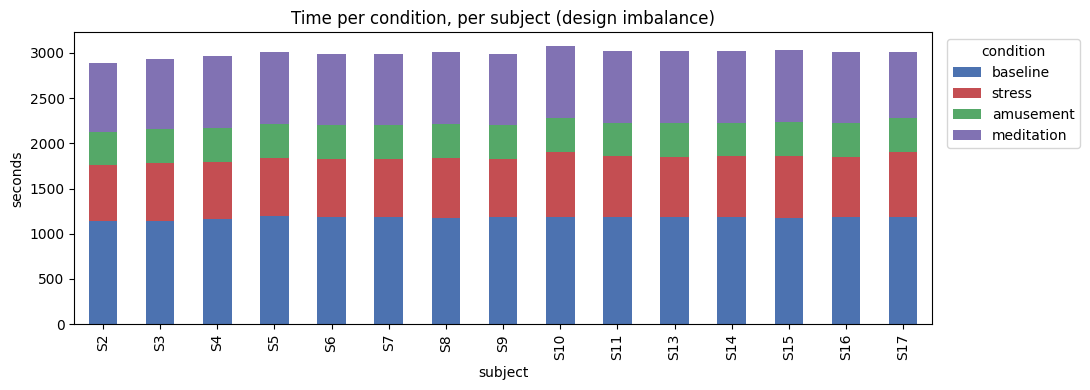

In [5]:
dur_rows = []
for s in SUBJECTS:
    d = load_subject(s)
    lab = np.asarray(d["label"]).ravel()
    for cid, cname in CONDITIONS.items():
        secs = int((lab == cid).sum()) / FS["label"]
        dur_rows.append(dict(subject=s, condition=cname, seconds=secs))

dur = pd.DataFrame(dur_rows)
dur_wide = dur.pivot(index="subject", columns="condition", values="seconds").reindex(SUBJECTS)
dur_wide = dur_wide[[c for c in ["baseline", "stress", "amusement", "meditation"] if c in dur_wide]]
dur_wide.to_csv(TAB / "condition_durations_seconds.csv")

print("Median seconds per condition:")
print(dur_wide.median().round(1))

ax = dur_wide.plot(kind="bar", stacked=True, figsize=(11, 4),
                   color=[COND_COLOR[c] for c in dur_wide.columns])
ax.set_ylabel("seconds"); ax.set_title("Time per condition, per subject (design imbalance)")
ax.legend(title="condition", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "condition_durations.png", dpi=140); plt.show()

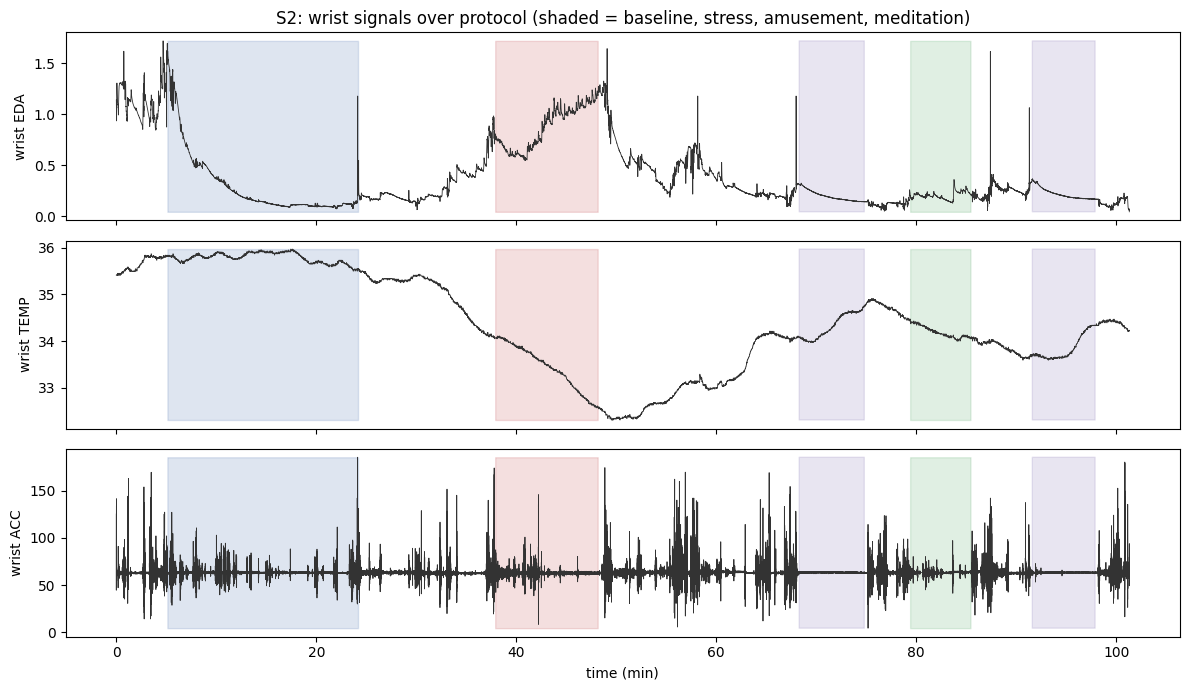

In [6]:
def plot_subject_timeline(subj, save=True):
    d = load_subject(subj)
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for ax, ch in zip(axes, ["EDA", "TEMP", "ACC"]):
        sig, fs = get_channel(d, "wrist", ch)
        lab = labels_for(d, fs, len(sig))
        t = np.arange(len(sig)) / fs / 60  # minutes
        ax.plot(t, sig, lw=0.6, color="0.2")
        # shade condition spans
        for cid, cname in CONDITIONS.items():
            mask = lab == cid
            if mask.any():
                ax.fill_between(t, sig.min(), sig.max(), where=mask,
                                color=COND_COLOR[cname], alpha=0.18, step="mid")
        ax.set_ylabel(f"wrist {ch}")
    axes[-1].set_xlabel("time (min)")
    axes[0].set_title(f"{subj}: wrist signals over protocol "
                      f"(shaded = " + ", ".join(f"{c}" for c in COND_COLOR) + ")")
    plt.tight_layout()
    if save:
        plt.savefig(FIG / f"timeline_{subj}.png", dpi=140)
    plt.show()

plot_subject_timeline(SUBJECTS[0])

/tmp/ipykernel_1748679/3841750027.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a for a in arrs], labels=[s.replace("S", "") for s in SUBJECTS],
/tmp/ipykernel_1748679/3841750027.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a for a in arrs], labels=[s.replace("S", "") for s in SUBJECTS],
/tmp/ipykernel_1748679/3841750027.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a for a in arrs], labels=[s.replace("S", "") for s in SUBJECTS],


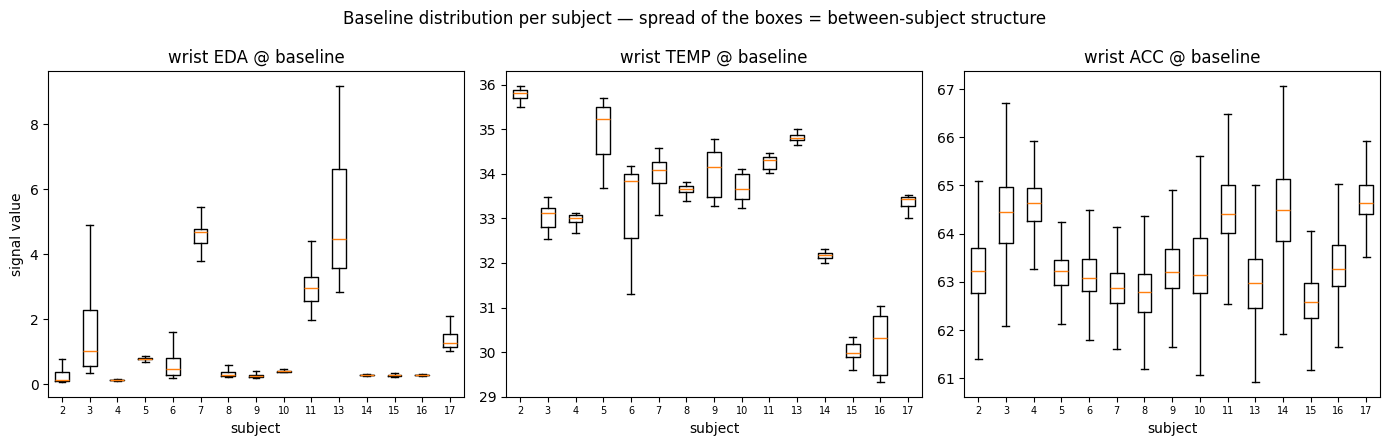

  location channel  icc_like  between_var  within_var
0    wrist     EDA    0.8518       2.7387      0.4766
1    wrist    TEMP    0.9455       2.5426      0.1464
2    wrist     ACC    0.0862       0.5293      5.6104

Reading: ICC-like near 1 => baseline is dominated by subject identity.
=> justifies LOSO, subject-normalization, and mixed models over pooled tests.


In [7]:
def baseline_samples(subj, location, channel):
    d = load_subject(subj)
    sig, fs = get_channel(d, location, channel)
    lab = labels_for(d, fs, len(sig))
    return sig[lab == 1]  # condition 1 = baseline


def icc_like(per_subject_arrays):
    """between-subject variance of means / (that + mean within-subject variance)."""
    means = np.array([a.mean() for a in per_subject_arrays if len(a)])
    within = np.array([a.var(ddof=1) for a in per_subject_arrays if len(a) > 1])
    between_var = means.var(ddof=1)
    within_var = within.mean()
    return between_var / (between_var + within_var), between_var, within_var


channels = [("wrist", "EDA"), ("wrist", "TEMP"), ("wrist", "ACC")]

fig, axes = plt.subplots(1, len(channels), figsize=(14, 4.5))
summary = []
for ax, (loc, ch) in zip(axes, channels):
    arrs = [baseline_samples(s, loc, ch) for s in SUBJECTS]
    # downsample points for a readable boxplot but keep full stats
    ax.boxplot([a for a in arrs], labels=[s.replace("S", "") for s in SUBJECTS],
               showfliers=False)
    ax.set_title(f"{loc} {ch} @ baseline")
    ax.set_xlabel("subject"); ax.tick_params(axis="x", labelsize=7)
    icc, bv, wv = icc_like(arrs)
    summary.append(dict(location=loc, channel=ch, icc_like=icc,
                        between_var=bv, within_var=wv))
axes[0].set_ylabel("signal value")
plt.suptitle("Baseline distribution per subject — spread of the boxes = between-subject structure")
plt.tight_layout(); plt.savefig(FIG / "baseline_between_subject.png", dpi=140); plt.show()

icc_df = pd.DataFrame(summary)
icc_df.to_csv(TAB / "baseline_icc_like.csv", index=False)
print(icc_df)
print("\nReading: ICC-like near 1 => baseline is dominated by subject identity.")
print("=> justifies LOSO, subject-normalization, and mixed models over pooled tests.")

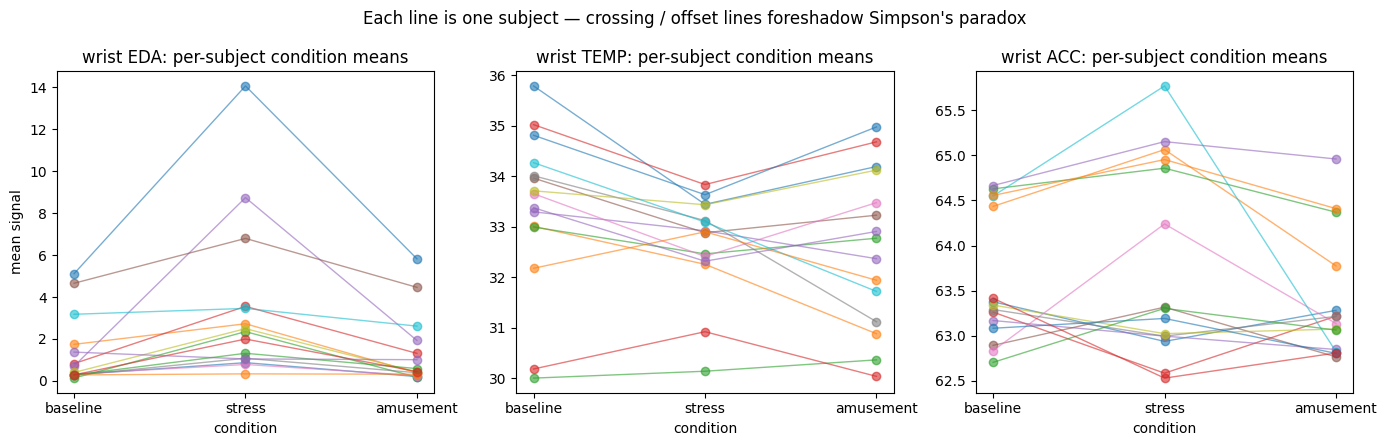

,subject,location,channel,condition,mean,std,n
0,S2,wrist,EDA,baseline,0.2979,0.3093,4576
1,S2,wrist,EDA,stress,0.8703,0.2045,2460
2,S2,wrist,EDA,amusement,0.2062,0.0383,1448
3,S2,wrist,TEMP,baseline,35.7862,0.1085,4576
4,S2,wrist,TEMP,stress,33.4421,0.4627,2460
5,S2,wrist,TEMP,amusement,34.1909,0.1203,1448
6,S2,wrist,ACC,baseline,63.3767,3.3865,36608
7,S2,wrist,ACC,stress,62.9370,2.7373,19680
8,S2,wrist,ACC,amusement,63.2812,1.5144,11584


In [8]:
rows = []
for s in SUBJECTS:
    d = load_subject(s)
    for loc, ch in channels:
        sig, fs = get_channel(d, loc, ch)
        lab = labels_for(d, fs, len(sig))
        for cid, cname in MODEL_STATES.items():
            v = sig[lab == cid]
            if len(v):
                rows.append(dict(subject=s, location=loc, channel=ch,
                                 condition=cname, mean=v.mean(),
                                 std=v.std(ddof=1) if len(v) > 1 else np.nan,
                                 n=len(v)))

feat = pd.DataFrame(rows)
feat.to_csv(TAB / "subject_condition_means.csv", index=False)

order = ["baseline", "stress", "amusement"]
fig, axes = plt.subplots(1, len(channels), figsize=(14, 4.5))
for ax, (loc, ch) in zip(axes, channels):
    sub = feat[(feat.location == loc) & (feat.channel == ch)]
    for s in SUBJECTS:
        line = sub[sub.subject == s].set_index("condition")["mean"].reindex(order)
        ax.plot(order, line.values, marker="o", lw=1, alpha=0.6)
    ax.set_title(f"{loc} {ch}: per-subject condition means")
    ax.set_xlabel("condition")
axes[0].set_ylabel("mean signal")
plt.suptitle("Each line is one subject — crossing / offset lines foreshadow Simpson's paradox")
plt.tight_layout(); plt.savefig(FIG / "per_subject_condition_means.png", dpi=140); plt.show()

feat.head(9)

In [ ]:
from pathlib import Path
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

warnings.filterwarnings("ignore", category=RuntimeWarning)

# >>> SET THIS to your WESAD root on Compute Canada <<<
DATA_DIR = Path("WESAD/")

SUBJECTS = [f"S{i}" for i in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]]
FS = {"label": 700, "chest": 700, "wrist_ACC": 32, "wrist_BVP": 64,
      "wrist_EDA": 4, "wrist_TEMP": 4}
MODEL_STATES = {1: "baseline", 2: "stress", 3: "amusement"}

WINDOW_SEC = 60
SHIFT_SEC  = 60          # non-overlapping (default; nb 03 re-runs with overlap to show leakage)
PURITY     = 0.90
ACC_TO_G   = 64.0        # wrist ACC raw counts -> g

# Feature bookkeeping -----------------------------------------------------------
# GATED  : allowed to be NaN (HRV, quality-gated). Never used to drop windows; never imputed blindly.
# TRUSTED: the feature set the classifier is allowed to see (nb 03/05).
# ppg_quality is a covariate / confound probe, not a model input.
GATED_FEATURES   = ["hrv_sdnn", "hrv_rmssd", "hrv_pnn50"]
UNTRUSTED_EXTRA  = ["hr_std"] + GATED_FEATURES          # kept in CSV, excluded from model
TRUSTED_FEATURES = ["eda_mean","eda_std","eda_min","eda_max","eda_slope","eda_scr_count",
                    "temp_mean","temp_std","temp_min","temp_max","temp_slope",
                    "hr_mean",
                    "acc_std","acc_energy","acc_mad","acc_max"]

OUT = Path("outputs"); TAB = OUT/"tables"; FIG = OUT/"figures"
TAB.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)


def load_subject(subj, data_dir=DATA_DIR):
    with open(Path(data_dir)/subj/f"{subj}.pkl", "rb") as f:
        return pickle.load(f, encoding="latin1")


def get_channel(data, location, channel):
    sig = np.asarray(data["signal"][location][channel], dtype=float)
    if channel == "ACC":
        sig = np.sqrt((sig**2).sum(axis=1))
        fs = FS[f"{location}_ACC"] if location == "wrist" else FS["chest"]
        if location == "wrist":
            sig = sig / ACC_TO_G
    else:
        sig = sig.ravel()
        fs = FS.get(f"{location}_{channel}", FS["chest"])
    return sig, fs

print("setup ok |", len(TRUSTED_FEATURES), "trusted features |",
      "untrusted/gated:", UNTRUSTED_EXTRA)

setup ok | 16 trusted features | untrusted/gated: ['hr_std', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50']


In [14]:
def _bandpass(x, fs, lo, hi, order=3):
    ny = 0.5*fs; b, a = butter(order, [lo/ny, hi/ny], btype="band"); return filtfilt(b, a, x)


def eda_features(x, fs):
    x = np.asarray(x, float)
    if len(x) < 4:
        return dict.fromkeys(["eda_mean","eda_std","eda_min","eda_max","eda_slope","eda_scr_count"], np.nan)
    t = np.arange(len(x))/fs; coef = np.polyfit(t, x, 1)
    detr = x - np.polyval(coef, t)
    peaks, _ = find_peaks(detr, prominence=0.01)
    return dict(eda_mean=x.mean(), eda_std=x.std(ddof=1), eda_min=x.min(),
                eda_max=x.max(), eda_slope=coef[0], eda_scr_count=float(len(peaks)))


def temp_features(x, fs):
    x = np.asarray(x, float)
    if len(x) < 4:
        return dict.fromkeys(["temp_mean","temp_std","temp_min","temp_max","temp_slope"], np.nan)
    t = np.arange(len(x))/fs; slope = np.polyfit(t, x, 1)[0]
    return dict(temp_mean=x.mean(), temp_std=x.std(ddof=1), temp_min=x.min(),
                temp_max=x.max(), temp_slope=slope)


def bvp_features(x, fs):
    """E4 wrist PPG -> cardiac features, scipy-only, quality-gated (see notebook header)."""
    keys = ["hr_mean","hr_std","hrv_sdnn","hrv_rmssd","hrv_pnn50","ppg_quality"]
    x = np.asarray(x, float).ravel()
    if len(x) < fs*5 or np.allclose(x.std(), 0):
        return dict.fromkeys(keys, np.nan)
    try:
        xf = _bandpass(x, fs, 0.5, 4.0)
    except Exception:
        return dict.fromkeys(keys, np.nan)
    xf = (xf - xf.mean())/(xf.std() + 1e-9)
    peaks, _ = find_peaks(xf, distance=int(0.4*fs), prominence=0.5)
    if len(peaks) < 5:
        return dict.fromkeys(keys, np.nan)
    ibi = np.diff(peaks)/fs*1000.0
    ibi_ok = ibi[(ibi > 300) & (ibi < 1600)]
    if len(ibi_ok) < 4:
        return dict(hr_mean=np.nan, hr_std=np.nan, hrv_sdnn=np.nan,
                    hrv_rmssd=np.nan, hrv_pnn50=np.nan, ppg_quality=0.0)
    med = np.median(ibi_ok)
    clean = ibi_ok[np.abs(ibi_ok - med) < 0.30*med]
    quality = len(clean)/len(ibi)
    hr = 60000.0/ibi_ok
    out = dict(hr_mean=float(hr.mean()), hr_std=float(hr.std(ddof=1)), ppg_quality=float(quality))
    if quality >= 0.80 and len(clean) >= 4:
        out.update(hrv_sdnn=float(clean.std(ddof=1)),
                   hrv_rmssd=float(np.sqrt(np.mean(np.diff(clean)**2))),
                   hrv_pnn50=float(np.mean(np.abs(np.diff(clean)) > 50)*100))
    else:
        out.update(hrv_sdnn=np.nan, hrv_rmssd=np.nan, hrv_pnn50=np.nan)
    return out


def acc_features(mag, fs):
    mag = np.asarray(mag, float)
    if len(mag) < 4:
        return dict.fromkeys(["acc_std","acc_energy","acc_mad","acc_max"], np.nan)
    d = np.abs(np.diff(mag))
    return dict(acc_std=mag.std(ddof=1), acc_energy=float(np.mean((mag - mag.mean())**2)),
                acc_mad=float(d.mean()), acc_max=mag.max())

print("feature functions defined")

feature functions defined


In [15]:
def window_label(data, t0, t1, purity=PURITY):
    lab = np.asarray(data["label"]).ravel()
    i0, i1 = int(t0*FS["label"]), int(t1*FS["label"])
    seg = lab[i0:i1]
    if len(seg) == 0:
        return None
    affect = seg[np.isin(seg, list(MODEL_STATES))]
    if len(affect) == 0:
        return None
    vals, counts = np.unique(affect, return_counts=True)
    top = int(vals[counts.argmax()])
    if counts.max()/len(seg) < purity:
        return None
    return top


def extract_subject(subj, window_sec=WINDOW_SEC, shift_sec=SHIFT_SEC):
    d = load_subject(subj)
    dur = len(np.asarray(d["label"]))/FS["label"]
    chans = {ch: get_channel(d, "wrist", ch) for ch in ["EDA", "TEMP", "BVP", "ACC"]}
    rows, t0 = [], 0.0
    while t0 + window_sec <= dur:
        t1 = t0 + window_sec
        lab = window_label(d, t0, t1)
        if lab is not None:
            rec = dict(subject=subj, condition=lab, condition_name=MODEL_STATES[lab], t_start=round(t0, 3))
            for ch, (sig, fs) in chans.items():
                seg = sig[int(t0*fs):int(t1*fs)]
                if ch == "EDA":   rec.update(eda_features(seg, fs))
                elif ch == "TEMP": rec.update(temp_features(seg, fs))
                elif ch == "BVP":  rec.update(bvp_features(seg, fs))
                elif ch == "ACC":  rec.update(acc_features(seg, fs))
            rows.append(rec)
        t0 += shift_sec
    return rows

print("windowing defined")

windowing defined


In [16]:
all_rows = []
for s in SUBJECTS:
    r = extract_subject(s); all_rows.extend(r)
    print(f"{s}: {len(r):4d} windows")

feat = pd.DataFrame(all_rows)
print("\nTotal windows:", len(feat))
print("\nClass balance:"); print(feat["condition_name"].value_counts())

S2:   33 windows
S3:   33 windows
S4:   33 windows
S5:   35 windows
S6:   34 windows
S7:   35 windows
S8:   35 windows
S9:   34 windows
S10:   35 windows
S11:   35 windows
S13:   35 windows
S14:   36 windows
S15:   36 windows
S16:   35 windows
S17:   36 windows

Total windows: 520

Class balance:
condition_name
baseline     283
stress       155
amusement     82
Name: count, dtype: int64


In [17]:
core = [c for c in feat.columns
        if c not in {"subject", "condition", "condition_name", "t_start"}
        and c not in GATED_FEATURES]

na_core = feat[core].isna().mean().sort_values(ascending=False)
print("NaN rate, CORE features (expected ~0):")
print(na_core[na_core > 0] if (na_core > 0).any() else "  all zero")

before = len(feat)
feat_clean = feat.dropna(subset=core).reset_index(drop=True)   # HRV NaNs preserved
print(f"\nDropped {before - len(feat_clean)}/{before} windows on missing CORE features "
      f"({100*(before-len(feat_clean))/before:.1f}%)")

hrv_avail = feat_clean["hrv_rmssd"].notna().mean()
print(f"HRV available on {hrv_avail*100:.0f}% of kept windows "
      f"(NaN elsewhere BY DESIGN -- not dropped, not imputed here)")

print("\nClass balance after cleaning:")
print(feat_clean["condition_name"].value_counts())
print("\nWindows per subject (should be ~30-36 each):")
print(feat_clean.groupby("subject").size().reindex(SUBJECTS))

NaN rate, CORE features (expected ~0):
  all zero

Dropped 0/520 windows on missing CORE features (0.0%)
HRV available on 48% of kept windows (NaN elsewhere BY DESIGN -- not dropped, not imputed here)

Class balance after cleaning:
condition_name
baseline     283
stress       155
amusement     82
Name: count, dtype: int64

Windows per subject (should be ~30-36 each):
subject
S2     33
S3     33
S4     33
S5     35
S6     34
S7     35
S8     35
S9     34
S10    35
S11    35
S13    35
S14    36
S15    36
S16    35
S17    36
dtype: int64


In [18]:
stamp = f"w{WINDOW_SEC}_s{SHIFT_SEC}"
csv_path = TAB/f"wrist_features_{stamp}.csv"
feat_clean.to_csv(csv_path, index=False)
print("wrote", csv_path, "shape", feat_clean.shape)

pd.Series(dict(window_sec=WINDOW_SEC, shift_sec=SHIFT_SEC, purity=PURITY,
               n_windows=len(feat_clean),
               hrv_available_frac=round(float(feat_clean["hrv_rmssd"].notna().mean()), 3),
               subjects=len(SUBJECTS))).to_csv(TAB/f"feature_provenance_{stamp}.csv")

pd.DataFrame({"feature": TRUSTED_FEATURES + UNTRUSTED_EXTRA,
              "trusted": [True]*len(TRUSTED_FEATURES) + [False]*len(UNTRUSTED_EXTRA)}
             ).to_csv(TAB/"feature_trust.csv", index=False)
print("wrote feature_trust.csv (trusted vs untrusted/gated)")
feat_clean.head()

wrote outputs/tables/wrist_features_w60_s60.csv shape (520, 25)
wrote feature_trust.csv (trusted vs untrusted/gated)


,subject,condition,condition_name,t_start,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_scr_count,...,hr_mean,hr_std,ppg_quality,hrv_sdnn,hrv_rmssd,hrv_pnn50,acc_std,acc_energy,acc_mad,acc_max
0,S2,1,baseline,360.0000,0.8888,0.1524,0.6794,1.1985,-0.0086,5.0000,...,77.9840,21.2201,0.7429,NaN,NaN,NaN,0.0349,0.0012,0.0190,1.2829
1,S2,1,baseline,420.0000,0.5811,0.0691,0.4744,0.7204,-0.0038,6.0000,...,78.3016,19.6630,0.8356,94.3203,136.2903,51.6667,0.0634,0.0040,0.0297,1.6792
2,S2,1,baseline,480.0000,0.5053,0.0153,0.4680,0.5680,0.0001,7.0000,...,79.3246,24.3094,0.6812,NaN,NaN,NaN,0.0545,0.0030,0.0231,1.7299
3,S2,1,baseline,540.0000,0.4233,0.0378,0.3680,0.4936,-0.0022,0.0000,...,75.9486,13.2501,0.9306,72.9093,58.4634,34.8485,0.0168,0.0003,0.0103,1.2185
4,S2,1,baseline,600.0000,0.3455,0.0225,0.2975,0.3898,-0.0012,10.0000,...,83.4586,27.4549,0.6462,NaN,NaN,NaN,0.0743,0.0055,0.0419,1.6096


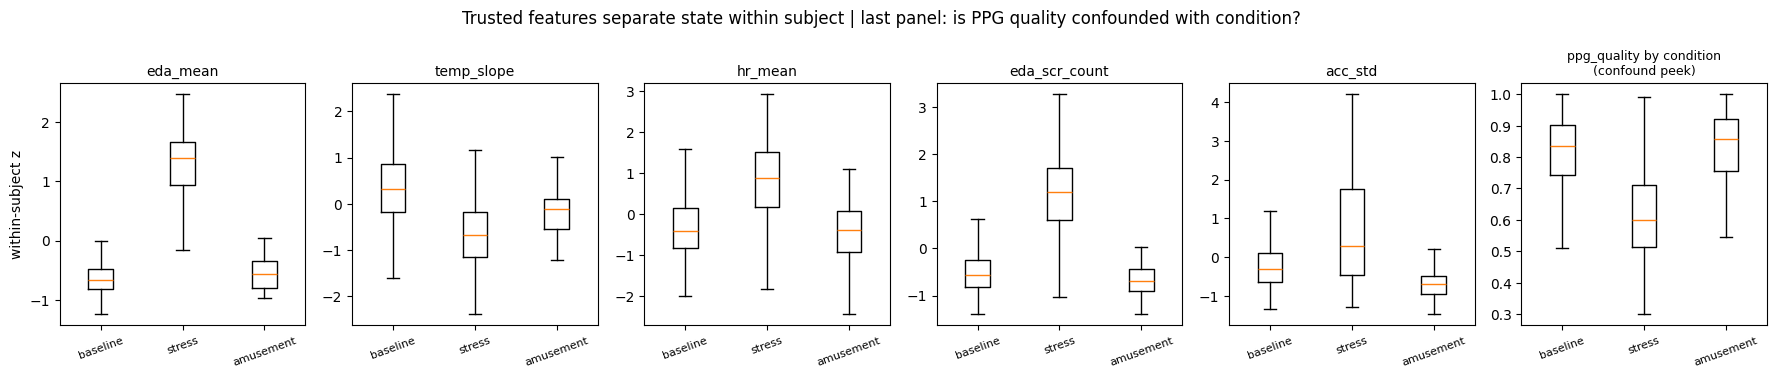

PPG quality by condition:
                 mean  median  count
condition_name                      
baseline       0.8124  0.8356    283
stress         0.6191  0.6000    155
amusement      0.8250  0.8571     82


In [19]:
plot_feats = ["eda_mean", "temp_slope", "hr_mean", "eda_scr_count", "acc_std"]
plot_feats = [f for f in plot_feats if f in feat_clean.columns]
order = ["baseline", "stress", "amusement"]

z = feat_clean.copy()
z[plot_feats] = z.groupby("subject")[plot_feats].transform(lambda c: (c - c.mean())/(c.std(ddof=0) + 1e-9))

fig, axes = plt.subplots(1, len(plot_feats) + 1, figsize=(3*(len(plot_feats)+1), 3.8))
for ax, f in zip(axes[:-1], plot_feats):
    ax.boxplot([z.loc[z.condition_name == c, f].values for c in order], tick_labels=order, showfliers=False)
    ax.set_title(f, fontsize=10); ax.tick_params(axis="x", labelsize=8, rotation=20)
axes[0].set_ylabel("within-subject z")

# (b) ppg_quality by condition -- RAW (not z-scored): is signal quality confounded with label?
axes[-1].boxplot([feat_clean.loc[feat_clean.condition_name == c, "ppg_quality"].values for c in order],
                 tick_labels=order, showfliers=False)
axes[-1].set_title("ppg_quality by condition\n(confound peek)", fontsize=9)
axes[-1].tick_params(axis="x", labelsize=8, rotation=20)

fig.suptitle("Trusted features separate state within subject | last panel: is PPG quality confounded with condition?")
plt.tight_layout(); plt.savefig(FIG/"within_subject_feature_separation.png", dpi=140); plt.show()

q_by_c = feat_clean.groupby("condition_name")["ppg_quality"].agg(["mean", "median", "count"]).reindex(order)
print("PPG quality by condition:"); print(q_by_c)

In [20]:
#Leakage, Confounding & LOSO Generalization

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix, brier_score_loss

RANDOM_STATE = 0
TAB = Path("outputs/tables"); FIG = Path("outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)

feat = pd.read_csv(TAB / "wrist_features_w60_s60.csv")

# trusted feature list (from nb 02); fallback if the file isn't present
try:
    ft = pd.read_csv(TAB / "feature_trust.csv")
    TRUSTED = ft.loc[ft.trusted, "feature"].tolist()
except FileNotFoundError:
    TRUSTED = ["eda_mean","eda_std","eda_min","eda_max","eda_slope","eda_scr_count",
               "temp_mean","temp_std","temp_min","temp_max","temp_slope",
               "hr_mean","acc_std","acc_energy","acc_mad","acc_max"]
TRUSTED = [f for f in TRUSTED if f in feat.columns]
ACC_FEATS = [f for f in TRUSTED if f.startswith("acc_")]

X   = feat[TRUSTED].values
y   = feat["condition"].values           # 1=baseline 2=stress 3=amusement
grp = feat["subject"].values
print(f"{len(feat)} windows | {len(TRUSTED)} trusted features | {feat.subject.nunique()} subjects")
print("classes:", dict(zip(*np.unique(y, return_counts=True))))
print("ppg_quality and hr_std/hrv_* are NOT in X:", "ppg_quality" not in TRUSTED and "hr_std" not in TRUSTED)

520 windows | 16 trusted features | 15 subjects
classes: {1: 283, 2: 155, 3: 82}
ppg_quality and hr_std/hrv_* are NOT in X: True


In [21]:
order = [1, 2, 3]; names = {1:"baseline",2:"stress",3:"amusement"}

# (a) PPG quality by condition -- Kruskal-Wallis (non-parametric; quality is bounded/skewed)
groups_q = [feat.loc[feat.condition==c, "ppg_quality"].values for c in order]
H, p_q = stats.kruskal(*groups_q)
print("PPG quality by condition:")
for c in order:
    v = feat.loc[feat.condition==c, "ppg_quality"]
    print(f"  {names[c]:9s} median={v.median():.3f}  mean={v.mean():.3f}  n={len(v)}")
print(f"  Kruskal-Wallis H={H:.1f}, p={p_q:.2e}  -> quality {'IS' if p_q<0.05 else 'is not'} confounded with label\n")

# (b) HRV missingness by condition -- chi-square (is HRV missing-not-at-random w.r.t. label?)
feat["hrv_missing"] = feat["hrv_rmssd"].isna()
ct = pd.crosstab(feat["condition"].map(names), feat["hrv_missing"])
chi2, p_m, _, _ = stats.chi2_contingency(ct)
print("HRV missingness by condition (True = HRV unavailable):")
print(ct)
print(f"  chi2={chi2:.1f}, p={p_m:.2e}  -> HRV missingness {'IS' if p_m<0.05 else 'is not'} "
      f"confounded with label (MNAR) => do not impute HRV")

PPG quality by condition:
  baseline  median=0.836  mean=0.812  n=283
  stress    median=0.600  mean=0.619  n=155
  amusement median=0.857  mean=0.825  n=82
  Kruskal-Wallis H=159.8, p=2.02e-35  -> quality IS confounded with label

HRV missingness by condition (True = HRV unavailable):
hrv_missing  False  True 
condition                
amusement       53     29
baseline       178    105
stress          16    139
  chi2=122.5, p=2.55e-27  -> HRV missingness IS confounded with label (MNAR) => do not impute HRV


pipeline         split  scaling  macro_F1  bal_acc            leak_sources
   naive random 5-fold   global    0.6914   0.7366 subject + normalization
 partial random 5-fold per-fold    0.6881   0.7343                 subject
  honest          LOSO per-fold    0.6299   0.6729                    none

  normalization-leakage inflation (naive - partial): +0.003 macro-F1
  SUBJECT-leakage inflation      (partial - honest): +0.058 macro-F1  <- the headline
  total inflation                (naive  - honest): +0.062 macro-F1


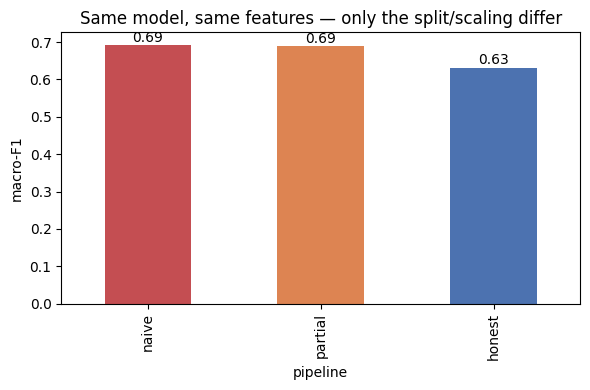

In [ ]:
def macro_f1_cv(estimator, X, y, cv, groups=None):
    yp = cross_val_predict(estimator, X, y, cv=cv, groups=groups)
    return f1_score(y, yp, average="macro"), balanced_accuracy_score(y, yp)

pipe = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=5000, class_weight="balanced"))
skf  = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
logo = LeaveOneGroupOut()

# (a) random CV + GLOBAL scaling (scale entire X up front -> leaks test stats into train)
Xg = StandardScaler().fit_transform(X)
f_a, b_a = macro_f1_cv(LogisticRegression(max_iter=5000, class_weight="balanced"), Xg, y, skf)
# (b) random CV + per-fold scaling (scaler inside pipeline) -- subject leakage remains
f_b, b_b = macro_f1_cv(pipe, X, y, skf)
# (c) LOSO + per-fold scaling 
f_c, b_c = macro_f1_cv(pipe, X, y, logo, groups=grp)

audit = pd.DataFrame([
    ["naive",   "random 5-fold", "global",   f_a, b_a, "subject + normalization"],
    ["partial", "random 5-fold", "per-fold", f_b, b_b, "subject"],
    ["honest",  "LOSO",          "per-fold", f_c, b_c, "none"],
], columns=["pipeline","split","scaling","macro_F1","bal_acc","leak_sources"])
audit.to_csv(TAB/"leakage_audit.csv", index=False)
print(audit.to_string(index=False))
print(f"\n  normalization-leakage inflation (naive - partial): {f_a-f_b:+.3f} macro-F1")
print(f"  SUBJECT-leakage inflation      (partial - honest): {f_b-f_c:+.3f} macro-F1  <- the headline")
print(f"  total inflation                (naive  - honest): {f_a-f_c:+.3f} macro-F1")

ax = audit.plot.bar(x="pipeline", y="macro_F1", legend=False, figsize=(6,4),
                    color=["#C44E52","#DD8452","#4C72B0"])
ax.set_ylabel("macro-F1"); ax.set_title("Same model, same features — only the split/scaling differ")
for i,v in enumerate(audit.macro_F1): ax.text(i, v+.01, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.savefig(FIG/"leakage_audit.png", dpi=140); plt.show()

In [23]:
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced")
f_hgb_rand, _ = macro_f1_cv(hgb, X, y, skf)
f_hgb_loso, _ = macro_f1_cv(hgb, X, y, logo, groups=grp)
print(f"HistGradientBoosting  random-CV macro-F1 = {f_hgb_rand:.3f}")
print(f"HistGradientBoosting  LOSO      macro-F1 = {f_hgb_loso:.3f}")
print(f"  subject-leakage gap = {f_hgb_rand-f_hgb_loso:+.3f}  (compare LogReg {f_b-f_c:+.3f})")

HistGradientBoosting  random-CV macro-F1 = 0.854
HistGradientBoosting  LOSO      macro-F1 = 0.623
  subject-leakage gap = +0.231  (compare LogReg +0.058)


In [24]:
def loso_f1(cols):
    return macro_f1_cv(pipe, feat[cols].values, y, logo, groups=grp)[0]

chance = f1_score(y, np.full_like(y, pd.Series(y).mode()[0]), average="macro")
f_full   = loso_f1(TRUSTED)
f_no_acc = loso_f1([c for c in TRUSTED if c not in ACC_FEATS])
f_acc    = loso_f1(ACC_FEATS)
f_leakq  = loso_f1(TRUSTED + ["ppg_quality"])      # DEMO of confound only -- never ship this

print(f"chance (majority-class macro-F1)     : {chance:.3f}")
print(f"LOSO full trusted set                : {f_full:.3f}")
print(f"LOSO without motion (acc_* dropped)  : {f_no_acc:.3f}   (delta {f_no_acc-f_full:+.3f})")
print(f"LOSO motion ONLY (acc_* )            : {f_acc:.3f}   (vs chance {f_acc-chance:+.3f})")
print(f"LOSO + ppg_quality leaked in         : {f_leakq:.3f}   (delta {f_leakq-f_full:+.3f}) <- why it's banned")
pd.DataFrame(dict(setting=["chance","full","no_ACC","ACC_only","+ppg_quality(leak)"],
                  macro_F1=[chance,f_full,f_no_acc,f_acc,f_leakq])
             ).to_csv(TAB/"confounding_probe.csv", index=False)

chance (majority-class macro-F1)     : 0.235
LOSO full trusted set                : 0.630
LOSO without motion (acc_* dropped)  : 0.568   (delta -0.062)
LOSO motion ONLY (acc_* )            : 0.522   (vs chance +0.287)
LOSO + ppg_quality leaked in         : 0.647   (delta +0.017) <- why it's banned


LOSO macro-F1: mean=0.611  sd=0.145  95% CI [0.537, 0.680]
  range across subjects: 0.333 (S13) to 0.811 (S14)
  generalization gap (random-CV - LOSO): +0.078 macro-F1


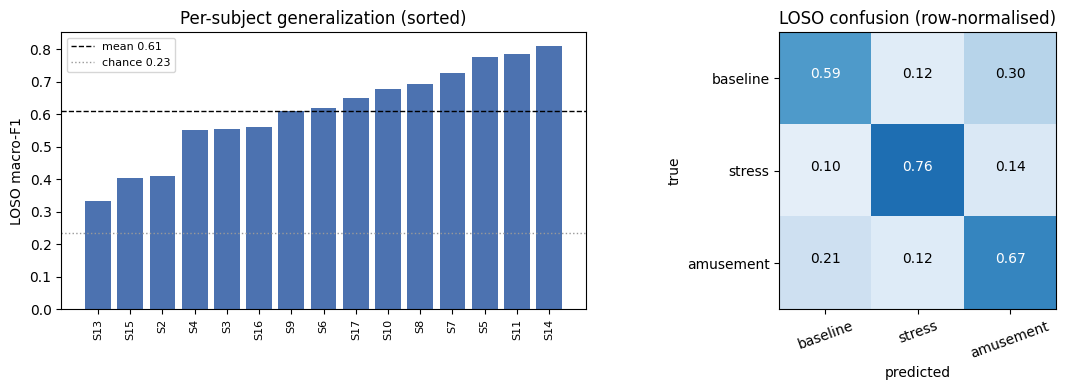

In [25]:
rng = np.random.default_rng(RANDOM_STATE)
per_subj, subj_ids = [], []
for tr, te in logo.split(X, y, grp):
    m = clone(pipe).fit(X[tr], y[tr])
    per_subj.append(f1_score(y[te], m.predict(X[te]), average="macro"))
    subj_ids.append(grp[te][0])
per_subj = np.array(per_subj)

boot = [rng.choice(per_subj, len(per_subj), replace=True).mean() for _ in range(5000)]
ci = np.percentile(boot, [2.5, 97.5])
print(f"LOSO macro-F1: mean={per_subj.mean():.3f}  sd={per_subj.std(ddof=1):.3f}  "
      f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"  range across subjects: {per_subj.min():.3f} ({subj_ids[per_subj.argmin()]}) "
      f"to {per_subj.max():.3f} ({subj_ids[per_subj.argmax()]})")
gap = f_b - per_subj.mean()
print(f"  generalization gap (random-CV - LOSO): {gap:+.3f} macro-F1")

pd.DataFrame(dict(subject=subj_ids, loso_macro_f1=per_subj)).to_csv(TAB/"loso_per_subject.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sidx = np.argsort(per_subj)
ax[0].bar(np.array(subj_ids)[sidx], per_subj[sidx], color="#4C72B0")
ax[0].axhline(per_subj.mean(), color="k", ls="--", lw=1, label=f"mean {per_subj.mean():.2f}")
ax[0].axhline(chance, color="0.6", ls=":", lw=1, label=f"chance {chance:.2f}")
ax[0].set_ylabel("LOSO macro-F1"); ax[0].set_title("Per-subject generalization (sorted)")
ax[0].tick_params(axis="x", rotation=90, labelsize=8); ax[0].legend(fontsize=8)

yp_loso = cross_val_predict(pipe, X, y, cv=logo, groups=grp)
cm = confusion_matrix(y, yp_loso, normalize="true")
im = ax[1].imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax[1].set_xticks(range(3)); ax[1].set_yticks(range(3))
ax[1].set_xticklabels([names[c] for c in order], rotation=20); ax[1].set_yticklabels([names[c] for c in order])
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true"); ax[1].set_title("LOSO confusion (row-normalised)")
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, f"{cm[i,j]:.2f}", ha="center",
                   color="white" if cm[i,j]>0.5 else "black")
plt.tight_layout(); plt.savefig(FIG/"loso_generalization.png", dpi=140); plt.show()

Multiclass Brier score (LOSO): 0.461   (0=perfect; lower is better)
Mean confidence 0.745 vs overall accuracy 0.652 -> over-confident


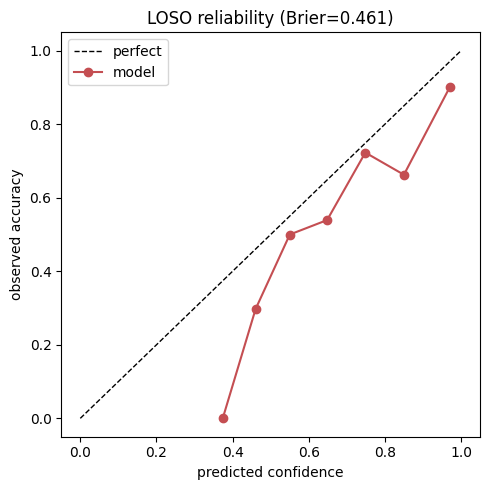

In [26]:
proba = cross_val_predict(pipe, X, y, cv=logo, groups=grp, method="predict_proba")
classes = np.unique(y)
conf = proba.max(axis=1)
pred = classes[proba.argmax(axis=1)]
correct = (pred == y).astype(float)

# multiclass Brier = mean sum_k (p_k - 1[y=k])^2
onehot = np.zeros_like(proba); 
for i,c in enumerate(classes): onehot[y==c, i] = 1
brier = float(np.mean(((proba - onehot)**2).sum(axis=1)))

bins = np.linspace(0,1,11); idx = np.digitize(conf, bins)-1
xs, ys, ns = [], [], []
for b in range(10):
    m = idx==b
    if m.sum()>0: xs.append(conf[m].mean()); ys.append(correct[m].mean()); ns.append(m.sum())
print(f"Multiclass Brier score (LOSO): {brier:.3f}   (0=perfect; lower is better)")
print(f"Mean confidence {conf.mean():.3f} vs overall accuracy {correct.mean():.3f} "
      f"-> {'over' if conf.mean()>correct.mean() else 'under'}-confident")

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"k--",lw=1,label="perfect")
plt.plot(xs, ys, "o-", color="#C44E52", label="model")
plt.xlabel("predicted confidence"); plt.ylabel("observed accuracy")
plt.title(f"LOSO reliability (Brier={brier:.3f})"); plt.legend(); plt.tight_layout()
plt.savefig(FIG/"calibration.png", dpi=140); plt.show()

In [27]:
#Designed-Experiment Statistics & Simpson's Paradox
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression

TAB = Path("outputs/tables"); FIG = Path("outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(TAB/"wrist_features_w60_s60.csv")
names = {1:"baseline", 2:"stress", 3:"amusement"}
feat["cond"] = feat["condition"].map(names)

# ~8 interpretable features spanning modalities -> keeps the multiple-comparison story legible
FEATURES = [f for f in ["eda_mean","eda_std","eda_scr_count","eda_slope",
                        "temp_mean","temp_slope","hr_mean","acc_std"] if f in feat.columns]
CONDS = ["baseline","stress","amusement"]
print(f"{len(feat)} windows | features tested: {FEATURES}")
print("windows per subject x condition (should be balanced-ish):")
print(feat.pivot_table(index="subject", columns="cond", values="eda_mean", aggfunc="count").reindex(columns=CONDS))


520 windows | features tested: ['eda_mean', 'eda_std', 'eda_scr_count', 'eda_slope', 'temp_mean', 'temp_slope', 'hr_mean', 'acc_std']
windows per subject x condition (should be balanced-ish):
cond     baseline  stress  amusement
subject                             
S10            19      11          5
S11            19      11          5
S13            19      10          6
S14            19      11          6
S15            19      11          6
S16            19      10          6
S17            19      11          6
S2             18      10          5
S3             18      10          5
S4             19       9          5
S5             19      10          6
S6             19      10          5
S7             19      10          6
S8             19      11          5
S9             19      10          5


In [28]:
def rm_anova_oneway(wide):
    """One-way repeated-measures ANOVA. wide: (n_subjects, k_conditions), balanced."""
    wide = np.asarray(wide, float); n, k = wide.shape
    grand = wide.mean(); cond_means = wide.mean(0); subj_means = wide.mean(1)
    ss_cond = n*((cond_means-grand)**2).sum()
    ss_subj = k*((subj_means-grand)**2).sum()
    ss_err  = ((wide-grand)**2).sum() - ss_cond - ss_subj
    df_cond, df_err = k-1, (k-1)*(n-1)
    F = (ss_cond/df_cond)/(ss_err/df_err); p = stats.f.sf(F, df_cond, df_err)
    peta2 = ss_cond/(ss_cond+ss_err)
    S = np.cov(wide, rowvar=False); dbar=np.mean(np.diag(S)); gbar=S.mean(); rowbar=S.mean(1)
    eps = np.clip(k**2*(dbar-gbar)**2 / ((k-1)*((S**2).sum()-2*k*(rowbar**2).sum()+k**2*gbar**2)), 1/(k-1), 1.0)
    return dict(F=F, p=p, partial_eta2=peta2, gg_epsilon=eps, p_gg=stats.f.sf(F, df_cond*eps, df_err*eps))

def bh_fdr(pvals):
    p=np.asarray(pvals); m=len(p); order=np.argsort(p)
    crit=np.minimum.accumulate((p[order]*m/np.arange(1,m+1))[::-1])[::-1]
    out=np.empty(m); out[order]=np.minimum(crit,1.0); return out

def holm(pvals):
    p=np.asarray(pvals); m=len(p); order=np.argsort(p); adj=np.empty(m); run=0
    for rank,idx in enumerate(order):
        run=max(run,(m-rank)*p[idx]); adj[idx]=min(run,1.0)
    return adj

def vif(X):
    X=np.asarray(X,float); out=[]
    for j in range(X.shape[1]):
        Z=np.delete(X,j,axis=1); r2=LinearRegression().fit(Z,X[:,j]).score(Z,X[:,j])
        out.append(1/(1-r2) if r2<1 else np.inf)
    return np.array(out)
print("primitives defined")

primitives defined


In [29]:
agg = feat.groupby(["subject","cond"])[FEATURES].mean().reset_index()

rows=[]
for f in FEATURES:
    wide = agg.pivot(index="subject", columns="cond", values=f)[CONDS].dropna()
    r = rm_anova_oneway(wide.values)
    rows.append(dict(feature=f, F=r["F"], p_raw=r["p"], p_gg=r["p_gg"],
                     partial_eta2=r["partial_eta2"], gg_epsilon=r["gg_epsilon"], n_subj=len(wide)))
res = pd.DataFrame(rows)
res["p_fdr"] = bh_fdr(res["p_gg"].values)
res["sig_raw"] = res["p_gg"] < 0.05
res["sig_fdr"] = res["p_fdr"] < 0.05
res = res.sort_values("p_fdr").reset_index(drop=True)
res.to_csv(TAB/"rm_anova_fdr.csv", index=False)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(res[["feature","F","partial_eta2","gg_epsilon","p_gg","p_fdr","sig_raw","sig_fdr"]].to_string(index=False))
lost = res[(res.sig_raw) & (~res.sig_fdr)]
print("\nSignificant uncorrected but NOT after FDR:", list(lost.feature) or "none",
      "\n(effect sizes matter as much as p: partial_eta2 is the practical magnitude)")

      feature     F  partial_eta2  gg_epsilon      p_gg     p_fdr  sig_raw  sig_fdr
eda_scr_count 37.43        0.7278      0.6611 2.208e-06 1.766e-05     True     True
   temp_slope 19.74         0.585      0.9018  1.15e-05   4.6e-05     True     True
      acc_std 24.91        0.6402      0.5575 0.0001011 0.0002695     True     True
      eda_std  12.1        0.4636      0.9944 0.0001691 0.0002706     True     True
      hr_mean 14.78        0.5136      0.8212 0.0001578 0.0002706     True     True
     eda_mean 9.844        0.4128      0.5225  0.006477  0.008637     True     True
    temp_mean  5.92        0.2972      0.9168   0.00903   0.01032     True     True
    eda_slope 6.016        0.3005      0.6419   0.01857   0.01857     True     True

Significant uncorrected but NOT after FDR: none 
(effect sizes matter as much as p: partial_eta2 is the practical magnitude)


In [30]:
pairs = [("baseline","stress"),("stress","amusement"),("baseline","amusement")]
ph=[]
for f in res[res.sig_fdr].feature:
    w = agg.pivot(index="subject", columns="cond", values=f)[CONDS].dropna()
    praw=[stats.ttest_rel(w[a], w[b]).pvalue for a,b in pairs]
    padj=holm(praw)
    for (a,b),pr,pa in zip(pairs,praw,padj):
        ph.append(dict(feature=f, contrast=f"{a} vs {b}",
                       mean_diff=w[a].mean()-w[b].mean(), p_holm=pa, sig=pa<0.05))
ph=pd.DataFrame(ph)
if len(ph):
    ph.to_csv(TAB/"posthoc_holm.csv", index=False)
    print(ph.to_string(index=False))
else:
    print("no FDR-significant features to follow up")

      feature              contrast  mean_diff    p_holm   sig
eda_scr_count    baseline vs stress     -10.82 6.195e-05  True
eda_scr_count   stress vs amusement      12.07 2.675e-05  True
eda_scr_count baseline vs amusement      1.245    0.1501 False
   temp_slope    baseline vs stress   0.001734 0.0001617  True
   temp_slope   stress vs amusement -0.0008527   0.01106  True
   temp_slope baseline vs amusement  0.0008812  0.003285  True
      acc_std    baseline vs stress   -0.03752  0.001101  True
      acc_std   stress vs amusement    0.05017 0.0001264  True
      acc_std baseline vs amusement    0.01265 0.0003721  True
      eda_std    baseline vs stress   -0.08493  0.001182  True
      eda_std   stress vs amusement    0.07674    0.0031  True
      eda_std baseline vs amusement  -0.008188    0.6757 False
      hr_mean    baseline vs stress     -11.49  0.002968  True
      hr_mean   stress vs amusement      11.38 0.0006748  True
      hr_mean baseline vs amusement    -0.1081    0.956

In [31]:
Z = feat[FEATURES].dropna().values
Zs = (Z - Z.mean(0))/Z.std(0)
v = pd.DataFrame(dict(feature=FEATURES, VIF=vif(Zs))).sort_values("VIF", ascending=False)
v.to_csv(TAB/"vif.csv", index=False)
print(v.to_string(index=False))
print("\nRule of thumb: VIF>5 notable, >10 severe. Collinear features -> don't interpret single coefficients.")

      feature   VIF
     eda_mean 5.874
eda_scr_count 5.339
      eda_std 2.288
      acc_std 1.644
    eda_slope 1.168
      hr_mean 1.083
   temp_slope  1.08
    temp_mean 1.048

Rule of thumb: VIF>5 notable, >10 severe. Collinear features -> don't interpret single coefficients.


In [32]:
from itertools import combinations
flips=[]
for fa, fb in combinations(FEATURES, 2):
    sub = feat[["subject",fa,fb]].dropna()
    pooled = np.corrcoef(sub[fa], sub[fb])[0,1]
    wr=[]
    for s,g in sub.groupby("subject"):
        if len(g)>=5 and g[fa].std()>0 and g[fb].std()>0:
            wr.append(np.corrcoef(g[fa], g[fb])[0,1])
    within = np.mean(wr)
    flips.append(dict(fa=fa, fb=fb, pooled_r=pooled, within_r=within,
                      sign_flip=(np.sign(pooled)!=np.sign(within)), gap=abs(pooled-within)))
flips=pd.DataFrame(flips).sort_values("gap", ascending=False)
flips.to_csv(TAB/"simpson_pairs.csv", index=False)
print("Feature pairs where pooled and within-subject correlations DISAGREE in sign:")
show = flips[flips.sign_flip]
print((show if len(show) else flips.head()).to_string(index=False))

Feature pairs where pooled and within-subject correlations DISAGREE in sign:
           fa        fb  pooled_r  within_r  sign_flip    gap
     eda_mean temp_mean    0.1775    -0.253       True 0.4305
eda_scr_count temp_mean    0.1209   -0.2711       True  0.392
      eda_std temp_mean     0.122   -0.1933       True 0.3154


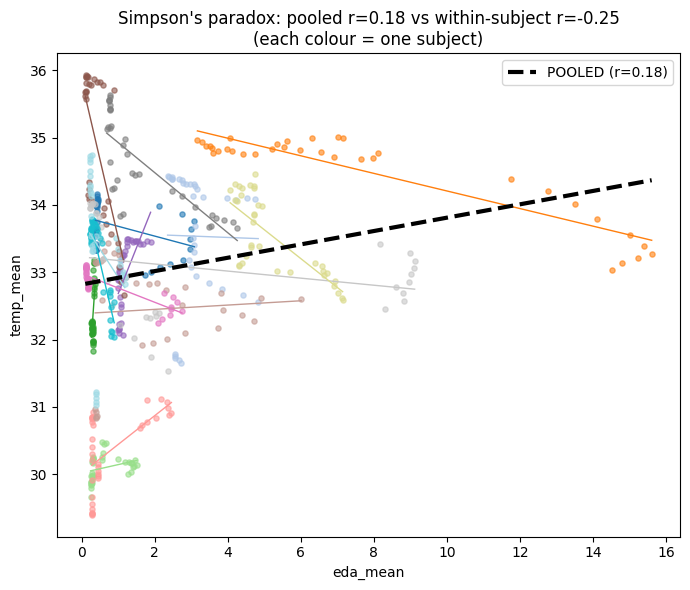

In [33]:
cand = flips[flips.sign_flip]
pair = (cand.iloc[0] if len(cand) else flips.iloc[0])
fa, fb = pair["fa"], pair["fb"]
sub = feat[["subject",fa,fb]].dropna()

plt.figure(figsize=(7,6))
cmap = plt.cm.tab20(np.linspace(0,1,sub.subject.nunique()))
for (s,g),c in zip(sub.groupby("subject"), cmap):
    plt.scatter(g[fa], g[fb], s=14, color=c, alpha=0.6)
    if len(g)>=3 and g[fa].std()>0:
        b=np.polyfit(g[fa],g[fb],1); xs=np.array([g[fa].min(),g[fa].max()]); plt.plot(xs, np.polyval(b,xs), color=c, lw=1)
bp=np.polyfit(sub[fa],sub[fb],1); xs=np.array([sub[fa].min(),sub[fa].max()])
plt.plot(xs, np.polyval(bp,xs), "k--", lw=3, label=f"POOLED (r={pair['pooled_r']:.2f})")
plt.xlabel(fa); plt.ylabel(fb)
plt.title(f"Simpson's paradox: pooled r={pair['pooled_r']:.2f} vs within-subject r={pair['within_r']:.2f}\n"
          f"(each colour = one subject)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG/"simpson_paradox.png", dpi=140); plt.show()

In [34]:
f0 = FEATURES[0] if flips.iloc[0]["fa"]=="__" else flips[flips.sign_flip].iloc[0]["fa"] if flips.sign_flip.any() else "temp_mean"
f0 = f0 if f0 in feat.columns else "eda_mean"
sub = feat[["subject","condition",f0]].dropna().copy()
sub["is_stress"] = (sub["condition"]==2).astype(int)
xz = (sub[[f0]].values - sub[[f0]].values.mean())/sub[[f0]].values.std()

pooled = LogisticRegression(max_iter=2000).fit(xz, sub.is_stress)
D = pd.get_dummies(sub["subject"], drop_first=True).values.astype(float)
withinX = np.hstack([xz, D])
withinm = LogisticRegression(max_iter=5000).fit(withinX, sub.is_stress)
print(f"Feature: {f0}  (predicting stress)")
print(f"  pooled logistic coef            : {pooled.coef_[0,0]:+.3f}")
print(f"  subject-fixed-effects coef      : {withinm.coef_[0,0]:+.3f}")
print("  => sign flip" if np.sign(pooled.coef_[0,0])!=np.sign(withinm.coef_[0,0])
      else "  => same sign (magnitude/So still shifts with subject adjustment)")

Feature: eda_mean  (predicting stress)
  pooled logistic coef            : +0.833
  subject-fixed-effects coef      : +2.535
  => same sign (magnitude/So still shifts with subject adjustment)


In [37]:
#Normalization Sweep: does per-subject calibration close the LOSO gap?

from pathlib import Path
import itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import f1_score

TAB = Path("outputs/tables"); FIG = Path("outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(TAB/"wrist_features_w60_s60.csv")

try:
    ft = pd.read_csv(TAB/"feature_trust.csv"); TRUSTED = ft.loc[ft.trusted,"feature"].tolist()
except FileNotFoundError:
    TRUSTED = ["eda_mean","eda_std","eda_min","eda_max","eda_slope","eda_scr_count",
               "temp_mean","temp_std","temp_min","temp_max","temp_slope",
               "hr_mean","acc_std","acc_energy","acc_mad","acc_max"]
TRUSTED = [f for f in TRUSTED if f in feat.columns]
print(f"{len(feat)} windows | {len(TRUSTED)} trusted features | {feat.subject.nunique()} subjects")


520 windows | 16 trusted features | 15 subjects


In [38]:
SPLITS=["random","loso"]; NORMS=["none","subject_z"]; MODELS=["logreg","hgb"]; SEEDS=list(range(10))

def subject_zscore(df, feats):
    out=df.copy()
    out[feats]=df.groupby("subject")[feats].transform(lambda c:(c-c.mean())/(c.std(ddof=0)+1e-9))
    return out

def make_model(name, seed):
    if name=="logreg":
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
    return HistGradientBoostingClassifier(random_state=seed, class_weight="balanced")

def evaluate(split, norm, model, seed):
    df = subject_zscore(feat, TRUSTED) if norm=="subject_z" else feat
    X,y,g = df[TRUSTED].values, df["condition"].values, df["subject"].values
    est = make_model(model, seed)
    if split=="random":
        skf=StratifiedKFold(5, shuffle=True, random_state=seed); yp=np.empty_like(y)
        for tr,te in skf.split(X,y):
            yp[te]=clone(est).fit(X[tr],y[tr]).predict(X[te])
        return f1_score(y,yp,average="macro"), None
    logo=LeaveOneGroupOut(); per={}
    for tr,te in logo.split(X,y,g):
        m=clone(est).fit(X[tr],y[tr]); per[str(g[te][0])]=f1_score(y[te],m.predict(X[te]),average="macro")
    return float(np.mean(list(per.values()))), per

records, per_subject = [], []
grid=list(itertools.product(SPLITS,NORMS,MODELS,SEEDS))
for i,(sp,nm,mo,sd) in enumerate(grid):
    f1, per = evaluate(sp,nm,mo,sd)
    records.append(dict(split=sp,norm=nm,model=mo,seed=sd,macro_f1=f1))
    if per:
        for subj,v in per.items():
            per_subject.append(dict(split=sp,norm=nm,model=mo,seed=sd,subject=subj,macro_f1=v))
    if (i+1)%10==0: print(f"  {i+1:2d}/{len(grid)} configs done")

res = pd.DataFrame(records); ps = pd.DataFrame(per_subject)
print("\nsweep complete:", dict(res.groupby(["split","norm","model"]).size().rename("n")))

  10/80 configs done
  20/80 configs done
  30/80 configs done
  40/80 configs done
  50/80 configs done
  60/80 configs done
  70/80 configs done
  80/80 configs done

sweep complete: {('loso', 'none', 'hgb'): 10, ('loso', 'none', 'logreg'): 10, ('loso', 'subject_z', 'hgb'): 10, ('loso', 'subject_z', 'logreg'): 10, ('random', 'none', 'hgb'): 10, ('random', 'none', 'logreg'): 10, ('random', 'subject_z', 'hgb'): 10, ('random', 'subject_z', 'logreg'): 10}


In [39]:
def boot_ci(vals, n=5000, seed=0):
    rng=np.random.default_rng(seed); vals=np.asarray(vals)
    bs=[rng.choice(vals,len(vals),replace=True).mean() for _ in range(n)]
    return vals.mean(), np.percentile(bs,2.5), np.percentile(bs,97.5)

loso = ps[ps.split=="loso"]
rows=[]
for (nm,mo),g in loso.groupby(["norm","model"]):
    per_subj=g.groupby("subject")["macro_f1"].mean().values
    m,lo,hi=boot_ci(per_subj)
    rows.append(dict(model=mo,norm=nm,loso_f1=m,ci_lo=lo,ci_hi=hi))
loso_tab=pd.DataFrame(rows).sort_values(["model","norm"]).reset_index(drop=True)
loso_tab.to_csv(TAB/"sweep_loso_norm.csv", index=False)
print(loso_tab.to_string(index=False))
for mo in loso_tab.model.unique():
    a=loso_tab[(loso_tab.model==mo)&(loso_tab.norm=="none")]["loso_f1"].values[0]
    b=loso_tab[(loso_tab.model==mo)&(loso_tab.norm=="subject_z")]["loso_f1"].values[0]
    print(f"  {mo}: subject_z {b-a:+.3f} macro-F1 vs raw ({'closes gap' if b>a else 'no gain'})")

 model      norm  loso_f1  ci_lo  ci_hi
   hgb      none   0.5875 0.5243 0.6534
   hgb subject_z   0.7147 0.6109 0.8126
logreg      none   0.6106 0.5371 0.6803
logreg subject_z   0.7484 0.6571 0.8293
  hgb: subject_z +0.127 macro-F1 vs raw (closes gap)
  logreg: subject_z +0.138 macro-F1 vs raw (closes gap)


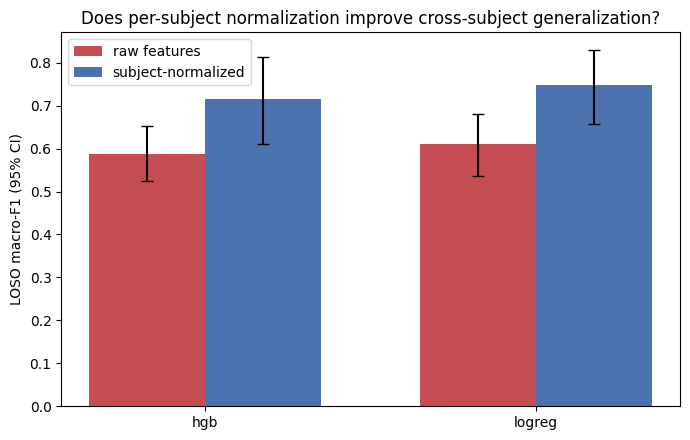

In [40]:
fig,ax=plt.subplots(figsize=(7,4.5))
models=loso_tab.model.unique(); x=np.arange(len(models)); w=0.35
for i,nm in enumerate(["none","subject_z"]):
    sub=loso_tab[loso_tab.norm==nm].set_index("model").reindex(models)
    err=np.vstack([sub.loso_f1-sub.ci_lo, sub.ci_hi-sub.loso_f1])
    ax.bar(x+(i-0.5)*w, sub.loso_f1, w, yerr=err, capsize=4,
           label=("raw features" if nm=="none" else "subject-normalized"), color=["#C44E52","#4C72B0"][i])
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylabel("LOSO macro-F1 (95% CI)")
ax.set_title("Does per-subject normalization improve cross-subject generalization?")
ax.legend(); plt.tight_layout(); plt.savefig(FIG/"sweep_normalization.png", dpi=140); plt.show()

In [41]:
summary=[]
for (nm,mo),_ in res.groupby(["norm","model"]):
    r=res[(res.split=="random")&(res.norm==nm)&(res.model==mo)].groupby("seed")["macro_f1"].mean().values
    rm,rlo,rhi=boot_ci(r)
    l=loso_tab[(loso_tab.norm==nm)&(loso_tab.model==mo)].iloc[0]
    summary.append(dict(norm=nm,model=mo,random_f1=rm,random_ci=f"[{rlo:.3f},{rhi:.3f}]",
                        loso_f1=l.loso_f1,loso_ci=f"[{l.ci_lo:.3f},{l.ci_hi:.3f}]",leakage_gap=rm-l.loso_f1))
summ=pd.DataFrame(summary).sort_values(["model","norm"]).reset_index(drop=True)
summ.to_csv(TAB/"sweep_leakage_summary.csv", index=False)
print(summ.to_string(index=False))
print("\nleakage_gap = random-CV minus honest LOSO (larger = more subject leakage exploited)")

     norm  model  random_f1     random_ci  loso_f1       loso_ci  leakage_gap
     none    hgb     0.8639 [0.860,0.868]   0.5875 [0.524,0.653]       0.2764
subject_z    hgb     0.8838 [0.878,0.889]   0.7147 [0.611,0.813]        0.169
     none logreg     0.6911 [0.685,0.697]   0.6106 [0.537,0.680]      0.08056
subject_z logreg     0.7974 [0.794,0.800]   0.7484 [0.657,0.829]      0.04896

leakage_gap = random-CV minus honest LOSO (larger = more subject leakage exploited)


In [42]:
#Normalization Sweep: does per-subject calibration close the LOSO gap?
from pathlib import Path
import itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import f1_score

TAB = Path("outputs/tables"); FIG = Path("outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(TAB/"wrist_features_w60_s60.csv")

try:
    ft = pd.read_csv(TAB/"feature_trust.csv"); TRUSTED = ft.loc[ft.trusted,"feature"].tolist()
except FileNotFoundError:
    TRUSTED = ["eda_mean","eda_std","eda_min","eda_max","eda_slope","eda_scr_count",
               "temp_mean","temp_std","temp_min","temp_max","temp_slope",
               "hr_mean","acc_std","acc_energy","acc_mad","acc_max"]
TRUSTED = [f for f in TRUSTED if f in feat.columns]
print(f"{len(feat)} windows | {len(TRUSTED)} trusted features | {feat.subject.nunique()} subjects")


520 windows | 16 trusted features | 15 subjects


In [43]:
SPLITS=["random","loso"]; NORMS=["none","subject_z"]; MODELS=["logreg","hgb"]; SEEDS=list(range(10))

def subject_zscore(df, feats):
    out=df.copy()
    out[feats]=df.groupby("subject")[feats].transform(lambda c:(c-c.mean())/(c.std(ddof=0)+1e-9))
    return out

def make_model(name, seed):
    if name=="logreg":
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
    return HistGradientBoostingClassifier(random_state=seed, class_weight="balanced")

def evaluate(split, norm, model, seed):
    df = subject_zscore(feat, TRUSTED) if norm=="subject_z" else feat
    X,y,g = df[TRUSTED].values, df["condition"].values, df["subject"].values
    est = make_model(model, seed)
    if split=="random":
        skf=StratifiedKFold(5, shuffle=True, random_state=seed); yp=np.empty_like(y)
        for tr,te in skf.split(X,y):
            yp[te]=clone(est).fit(X[tr],y[tr]).predict(X[te])
        return f1_score(y,yp,average="macro"), None
    logo=LeaveOneGroupOut(); per={}
    for tr,te in logo.split(X,y,g):
        m=clone(est).fit(X[tr],y[tr]); per[str(g[te][0])]=f1_score(y[te],m.predict(X[te]),average="macro")
    return float(np.mean(list(per.values()))), per

records, per_subject = [], []
grid=list(itertools.product(SPLITS,NORMS,MODELS,SEEDS))
for i,(sp,nm,mo,sd) in enumerate(grid):
    f1, per = evaluate(sp,nm,mo,sd)
    records.append(dict(split=sp,norm=nm,model=mo,seed=sd,macro_f1=f1))
    if per:
        for subj,v in per.items():
            per_subject.append(dict(split=sp,norm=nm,model=mo,seed=sd,subject=subj,macro_f1=v))
    if (i+1)%10==0: print(f"  {i+1:2d}/{len(grid)} configs done")

res = pd.DataFrame(records); ps = pd.DataFrame(per_subject)
print("\nsweep complete:", dict(res.groupby(["split","norm","model"]).size().rename("n")))

  10/80 configs done
  20/80 configs done
  30/80 configs done
  40/80 configs done
  50/80 configs done
  60/80 configs done
  70/80 configs done
  80/80 configs done

sweep complete: {('loso', 'none', 'hgb'): 10, ('loso', 'none', 'logreg'): 10, ('loso', 'subject_z', 'hgb'): 10, ('loso', 'subject_z', 'logreg'): 10, ('random', 'none', 'hgb'): 10, ('random', 'none', 'logreg'): 10, ('random', 'subject_z', 'hgb'): 10, ('random', 'subject_z', 'logreg'): 10}


In [44]:
def boot_ci(vals, n=5000, seed=0):
    rng=np.random.default_rng(seed); vals=np.asarray(vals)
    bs=[rng.choice(vals,len(vals),replace=True).mean() for _ in range(n)]
    return vals.mean(), np.percentile(bs,2.5), np.percentile(bs,97.5)

loso = ps[ps.split=="loso"]
rows=[]
for (nm,mo),g in loso.groupby(["norm","model"]):
    per_subj=g.groupby("subject")["macro_f1"].mean().values
    m,lo,hi=boot_ci(per_subj)
    rows.append(dict(model=mo,norm=nm,loso_f1=m,ci_lo=lo,ci_hi=hi))
loso_tab=pd.DataFrame(rows).sort_values(["model","norm"]).reset_index(drop=True)
loso_tab.to_csv(TAB/"sweep_loso_norm.csv", index=False)
print(loso_tab.to_string(index=False))
for mo in loso_tab.model.unique():
    a=loso_tab[(loso_tab.model==mo)&(loso_tab.norm=="none")]["loso_f1"].values[0]
    b=loso_tab[(loso_tab.model==mo)&(loso_tab.norm=="subject_z")]["loso_f1"].values[0]
    print(f"  {mo}: subject_z {b-a:+.3f} macro-F1 vs raw ({'closes gap' if b>a else 'no gain'})")

 model      norm  loso_f1  ci_lo  ci_hi
   hgb      none   0.5875 0.5243 0.6534
   hgb subject_z   0.7147 0.6109 0.8126
logreg      none   0.6106 0.5371 0.6803
logreg subject_z   0.7484 0.6571 0.8293
  hgb: subject_z +0.127 macro-F1 vs raw (closes gap)
  logreg: subject_z +0.138 macro-F1 vs raw (closes gap)


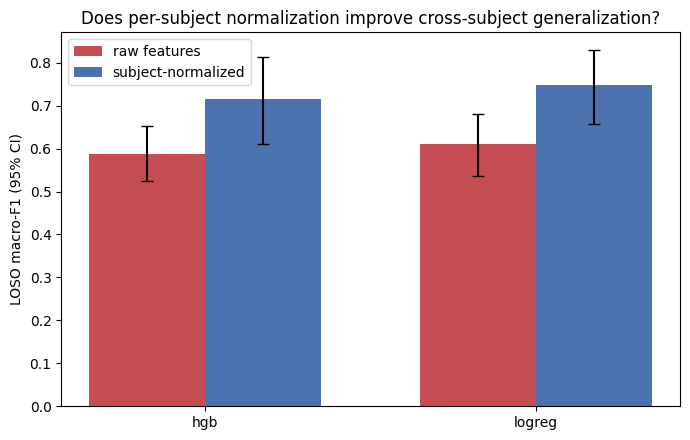

In [45]:
fig,ax=plt.subplots(figsize=(7,4.5))
models=loso_tab.model.unique(); x=np.arange(len(models)); w=0.35
for i,nm in enumerate(["none","subject_z"]):
    sub=loso_tab[loso_tab.norm==nm].set_index("model").reindex(models)
    err=np.vstack([sub.loso_f1-sub.ci_lo, sub.ci_hi-sub.loso_f1])
    ax.bar(x+(i-0.5)*w, sub.loso_f1, w, yerr=err, capsize=4,
           label=("raw features" if nm=="none" else "subject-normalized"), color=["#C44E52","#4C72B0"][i])
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylabel("LOSO macro-F1 (95% CI)")
ax.set_title("Does per-subject normalization improve cross-subject generalization?")
ax.legend(); plt.tight_layout(); plt.savefig(FIG/"sweep_normalization.png", dpi=140); plt.show()

In [46]:
summary=[]
for (nm,mo),_ in res.groupby(["norm","model"]):
    r=res[(res.split=="random")&(res.norm==nm)&(res.model==mo)].groupby("seed")["macro_f1"].mean().values
    rm,rlo,rhi=boot_ci(r)
    l=loso_tab[(loso_tab.norm==nm)&(loso_tab.model==mo)].iloc[0]
    summary.append(dict(norm=nm,model=mo,random_f1=rm,random_ci=f"[{rlo:.3f},{rhi:.3f}]",
                        loso_f1=l.loso_f1,loso_ci=f"[{l.ci_lo:.3f},{l.ci_hi:.3f}]",leakage_gap=rm-l.loso_f1))
summ=pd.DataFrame(summary).sort_values(["model","norm"]).reset_index(drop=True)
summ.to_csv(TAB/"sweep_leakage_summary.csv", index=False)
print(summ.to_string(index=False))
print("\nleakage_gap = random-CV minus honest LOSO (larger = more subject leakage exploited)")

     norm  model  random_f1     random_ci  loso_f1       loso_ci  leakage_gap
     none    hgb     0.8639 [0.860,0.868]   0.5875 [0.524,0.653]       0.2764
subject_z    hgb     0.8838 [0.878,0.889]   0.7147 [0.611,0.813]        0.169
     none logreg     0.6911 [0.685,0.697]   0.6106 [0.537,0.680]      0.08056
subject_z logreg     0.7974 [0.794,0.800]   0.7484 [0.657,0.829]      0.04896

leakage_gap = random-CV minus honest LOSO (larger = more subject leakage exploited)


                 method  loso_f1  ci_lo  ci_hi
   raw (no calibration)   0.6106 0.5371 0.6803
idealized (all windows)   0.7484 0.6571 0.8293
  rest-calibrated (n=3)   0.6007 0.5108 0.6902
  rest-calibrated (n=5)   0.6192 0.5563 0.6859
 rest-calibrated (n=10)     0.73 0.6556 0.8039


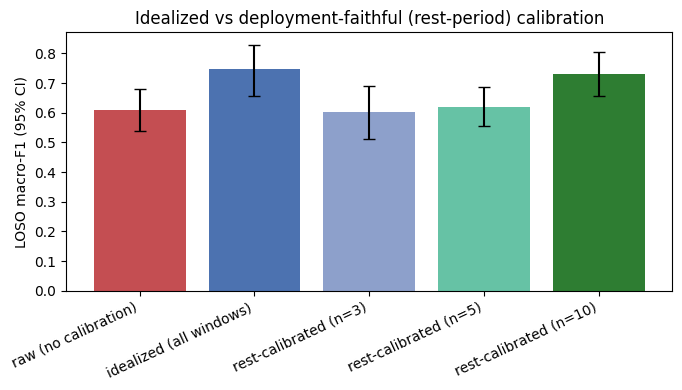

In [47]:
from sklearn.model_selection import LeaveOneGroupOut

def baseline_calibrate(df, feats, n_cal=5, cal_condition=1):
    df = df.reset_index(drop=True); out = df.copy(); gsd = df[feats].std(ddof=0); cal_idx = []
    for _, g in df.groupby("subject"):
        cal = g[g.condition == cal_condition].sort_values("t_start").head(n_cal)
        if len(cal) < 2: cal = g.sort_values("t_start").head(n_cal)
        cal_idx += list(cal.index)
        mu = df.loc[cal.index, feats].mean(); sd = df.loc[cal.index, feats].std(ddof=0).where(lambda s: s > 1e-6, gsd)
        out.loc[g.index, feats] = (df.loc[g.index, feats] - mu) / (sd + 1e-9)
    return out, df.index.isin(cal_idx)

def loso_rest_calibrated(df, feats, n_cal, seed=0):
    df = df.reset_index(drop=True); dfn, mask = baseline_calibrate(df, feats, n_cal)
    X, y, g = dfn[feats].values, df.condition.values, df.subject.values
    est = make_model("logreg", seed); per = {}
    for tr, te in LeaveOneGroupOut().split(X, y, g):
        te = te[~mask[te]]
        if len(te) == 0: continue
        per[str(g[te][0])] = f1_score(y[te], clone(est).fit(X[tr], y[tr]).predict(X[te]), average="macro")
    return np.array(list(per.values()))

_, raw_per   = evaluate("loso", "none", "logreg", 0)
_, ideal_per = evaluate("loso", "subject_z", "logreg", 0)
comp = [("raw (no calibration)", np.array(list(raw_per.values()))),
        ("idealized (all windows)", np.array(list(ideal_per.values())))]
for n_cal in [3, 5, 10]:
    comp.append((f"rest-calibrated (n={n_cal})", loso_rest_calibrated(feat, TRUSTED, n_cal)))

rows = [dict(method=name, loso_f1=(c:=boot_ci(v))[0], ci_lo=c[1], ci_hi=c[2]) for name, v in comp]
comp_tab = pd.DataFrame(rows); comp_tab.to_csv(TAB/"calibration_comparison.csv", index=False)
print(comp_tab.to_string(index=False))

plt.figure(figsize=(7,4))
err = np.vstack([comp_tab.loso_f1-comp_tab.ci_lo, comp_tab.ci_hi-comp_tab.loso_f1])
plt.bar(comp_tab.method, comp_tab.loso_f1, yerr=err, capsize=4,
        color=["#C44E52","#4C72B0","#8DA0CB","#66C2A5","#2E7D32"])
plt.ylabel("LOSO macro-F1 (95% CI)"); plt.xticks(rotation=25, ha="right")
plt.title("Idealized vs deployment-faithful (rest-period) calibration")
plt.tight_layout(); plt.savefig(FIG/"calibration_comparison.png", dpi=140); plt.show()

In [48]:
from scipy.stats import wilcoxon, ttest_rel
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.base import clone
from sklearn.metrics import f1_score

def _loso_per_subject(df, feats, model="logreg", seed=0):
    X, y, g = df[feats].values, df["condition"].values, df["subject"].values
    est = make_model(model, seed); per = {}
    for tr, te in LeaveOneGroupOut().split(X, y, g):
        m = clone(est).fit(X[tr], y[tr])
        per[str(g[te][0])] = f1_score(y[te], m.predict(X[te]), average="macro")
    return per

# paired per-subject LOSO macro-F1: same held-out subject, raw vs subject-normalized
raw_per  = _loso_per_subject(feat, TRUSTED)
norm_per = _loso_per_subject(subject_zscore(feat, TRUSTED), TRUSTED)

subs  = sorted(raw_per, key=lambda s: int(s[1:]))
raw   = np.array([raw_per[s]  for s in subs])
norm  = np.array([norm_per[s] for s in subs])
delta = norm - raw

print("per-subject LOSO macro-F1  (raw -> subject_z):")
for s, r, n, d in zip(subs, raw, norm, delta):
    print(f"  {s:>3}: {r:.3f} -> {n:.3f}   delta {d:+.3f}{'' if d >= 0 else '   (worse)'}")

n_up = int((delta > 0).sum())
w_stat, w_p = wilcoxon(norm, raw, alternative="greater")   # H1: subject_z > raw (paired, one-sided)
t_stat, t_p = ttest_rel(norm, raw)
rng = np.random.default_rng(0)
bs  = [rng.choice(delta, len(delta), replace=True).mean() for _ in range(10000)]

print(f"\nsubjects improved:  {n_up}/{len(subs)}")
print(f"mean paired delta   = {delta.mean():+.3f}  95% CI [{np.percentile(bs,2.5):+.3f}, {np.percentile(bs,97.5):+.3f}]")
print(f"median paired delta = {np.median(delta):+.3f}")
print(f"Wilcoxon signed-rank (one-sided, subject_z > raw): W={w_stat:.1f}, p={w_p:.4g}")
print(f"paired t-test (two-sided):                          t={t_stat:.2f}, p={t_p:.4g}")

pd.DataFrame({"subject": subs, "raw": raw, "subject_z": norm, "delta": delta}) \
  .to_csv(TAB/"paired_normalization_test.csv", index=False)

per-subject LOSO macro-F1  (raw -> subject_z):
   S2: 0.409 -> 0.772   delta +0.363
   S3: 0.554 -> 0.712   delta +0.158
   S4: 0.552 -> 0.731   delta +0.179
   S5: 0.777 -> 0.877   delta +0.100
   S6: 0.619 -> 0.791   delta +0.172
   S7: 0.726 -> 0.934   delta +0.208
   S8: 0.691 -> 0.900   delta +0.209
   S9: 0.609 -> 0.961   delta +0.351
  S10: 0.679 -> 0.704   delta +0.025
  S11: 0.785 -> 0.954   delta +0.168
  S13: 0.333 -> 0.699   delta +0.366
  S14: 0.811 -> 0.348   delta -0.463   (worse)
  S15: 0.404 -> 0.474   delta +0.070
  S16: 0.559 -> 0.802   delta +0.243
  S17: 0.649 -> 0.568   delta -0.081   (worse)

subjects improved:  13/15
mean paired delta   = +0.138  95% CI [+0.024, +0.227]
median paired delta = +0.172
Wilcoxon signed-rank (one-sided, subject_z > raw): W=102.0, p=0.007538
paired t-test (two-sided):                          t=2.58, p=0.02199


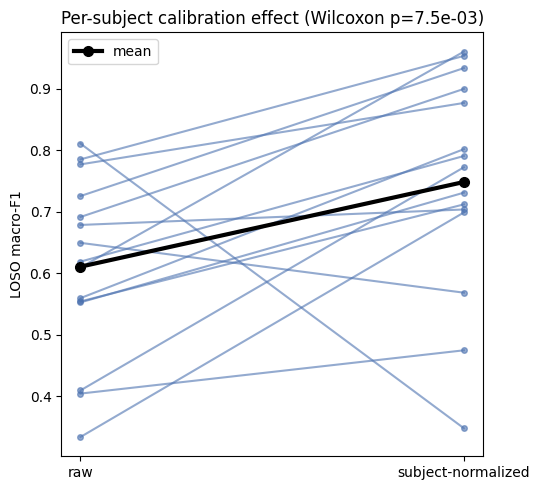

In [49]:
plt.figure(figsize=(5.5, 5))
for r, n in zip(raw, norm):
    plt.plot([0, 1], [r, n], "-o", color="#4C72B0", alpha=0.6, ms=4)
plt.plot([0, 1], [raw.mean(), norm.mean()], "-o", color="black", lw=3, ms=7, label="mean")
plt.xticks([0, 1], ["raw", "subject-normalized"]); plt.ylabel("LOSO macro-F1")
plt.title(f"Per-subject calibration effect (Wilcoxon p={w_p:.1e})")
plt.legend(); plt.tight_layout(); plt.savefig(FIG/"paired_normalization.png", dpi=140); plt.show()